In [151]:
import os
print(os.getcwd())
cwd = os.getcwd()
os.chdir('../../')
import rsnapsim as rsnp  # import the rsnapsim
os.chdir(cwd)


C:\Users\wsraymon\GitHub\rSNAPsim\rsnapsim\interactive_notebooks


In [152]:
import numpy as np
import matplotlib.pyplot as plt

In [153]:
# load a sequence file
# When we load a sequence file, several objects are returned:

# aaseq_dict - a dictionary of detected orfs reported as their amino acid sequences, keyed by frame
# cds_dict - a dictionary of detected orfs converted to CDS objects keyed by frame
# tagged_cdss - a dictionary of detected orfs with known fluorescent epitopes
# source_seq - a single string of the raw sequence pulled from the file

aaseq_dict, cds_dict, tagged_cdss, source_seq = rsnp.seqmanip.open_seq_file('../gene_files/NC_005816.gb', add_tag=False)

In [154]:
tagged_cdss

{'0': [], '+1': [], '+2': [], '-1': []}

In [155]:
# Lets look at how many valid coding regions were detected: 
cds_count = [len(cds_dict[x]) for x in ['0','+1','-1']]
print('cds count in the  %s frame: %i'%('0',cds_count[0]))
print('cds count in the %s frame: %i'%('+1',cds_count[1]))
print('cds count in the %s frame: %i'%('-1',cds_count[2]))


cds count in the  0 frame: 1
cds count in the +1 frame: 3
cds count in the -1 frame: 4


In [156]:
# lets take a look at what a CDS object contains
cds_dict['0'][0].__dict__

{'aa_seq': 'MKKSSIVATIITILSGSANAASSQLIPNISPDSFTVAASTGMLSGKSHEMLYDAETGRKISQLDWKIKNVAILKGDISWDPYSFLTLNARGWTSLASGSGNMDDYDWMNENQSEWTDHSSHPATNVNHANEYDLNVKGWLLQDENYKAGITAGYQETRFSWTATGGSYSYNNGAYTGNFPKGVRVIGYNQRFSMPYIGLAGQYRINDFELNALFKFSDWVRAHDNDEHYMRDLTFREKTSGSRYYGTVINAGYYVTPNAKVFAEFTYSKYDEGKGGTQIIDKNSGDSVSIGGDAAGISNKNYTVTAGLQYRF*',
 'nt_seq': 'AUGAAGAAAAGUUCUAUUGUGGCAACCAUUAUAACUAUUCUGUCCGGGAGUGCUAAUGCAGCAUCAUCUCAGUUAAUACCAAAUAUAUCCCCUGACAGCUUUACAGUUGCAGCCUCCACCGGGAUGCUGAGUGGAAAGUCUCAUGAAAUGCUUUAUGACGCAGAAACAGGAAGAAAGAUCAGCCAGUUAGACUGGAAGAUCAAAAAUGUCGCUAUCCUGAAAGGUGAUAUAUCCUGGGAUCCAUACUCAUUUCUGACCCUGAAUGCCAGGGGGUGGACGUCUCUGGCUUCCGGGUCAGGUAAUAUGGAUGACUACGACUGGAUGAAUGAAAAUCAAUCUGAGUGGACAGAUCACUCAUCUCAUCCUGCUACAAAUGUUAAUCAUGCCAAUGAAUAUGACCUCAAUGUGAAAGGCUGGUUACUCCAGGAUGAGAAUUAUAAAGCAGGUAUAACAGCAGGAUAUCAGGAAACACGUUUCAGUUGGACAGCUACAGGUGGUUCAUAUAGUUAUAAUAAUGGAGCUUAUACCGGAAACUUCCCGAAAGGAGUGCGGGUAAUAGGUUAUAACCAGCGCUUUUCUAUGCCAUAUAUUGGACUUGCAGGCCAGUAUCGCAUUAAUGAUUUUGAGUUAAAUGCAUUAUUUAAAUUCAGCGACUGGGUU

In [157]:
# how large is each open reading frame?
[[len(x.aa_seq) for x in cds_dict[y]] for y in ['0','+1','-1']]

[[313], [260, 146, 139], [341, 89, 81, 93]]

In [158]:
# lets simulate translation on the largest coding region. 
largest_CDS = cds_dict['+2'][0]

In [159]:
largest_CDS.aa_seq

'MVTFETVMEIKILHKQGMSSRAIARELGISRNTVKRYLQAKSEPPKYTPRPAVASLLDEYRDYIRQRIADAHPYKIPATVIAREIRDQGYRGGMTILRAFIRSLSVPQEQEPAVRFETEPGRQMQVDWGTMRNGRSPLHVFVAVLGYSRMLYIEFTDNMRYDTLETCHRNAFRFFGGVPREVLYDNMKTVVLQRDAYQTGQHRFHPSLWQFGKEMGFSPRLCRPFRAQTKGKVERMVQYTRNSFYIPLMTRLRPMGITVDVETANRHGLRWLHDVANQRKHETIQARPCDRWLEEQQSMLALPPEKKEYDVHLDENLVNFDKHPLHHPLSIYDSFCRGVA*'

So this protein is from yersinia pestis (plague) you can see the original NCBI genbank file here: https://www.ncbi.nlm.nih.gov/nuccore/NC_005816

In [160]:
# how do we solve a model?
rsnp.solver.solve_ssa?

# Currently the model solver takes 3 types of inputs: A custom model object, a CDS object, or a simple list of stepping rates
# whats happening in the background is the list and CDS objects are converted to a custom model object and then used for solving.
# If a list is provided, the additional arguments of ki, kt, and probe list (list of lists of locations) are required.


Signature:
rsnp.solver.solve_ssa(
    mRNA_model,
    t,
    n_traj=1,
    burnin=0,
    seed=None,
    parallel=False,
    cplus=False,
    cores=4,
    probe_list=None,
    ki=None,
    kt=None,
)
Docstring: <no docstring>
File:      c:\users\wsraymon\github\rsnapsim\rsnapsim\solver.py
Type:      method

In [161]:
#currently you can pass a CDS directly to the model solver, this is ambigious and needs to change!!
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(largest_CDS, t)

In [162]:
soln.intensity_arr.sum()

0

In [163]:
soln.__dict__

{'ribosome_array': array([[[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         ...,
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
 
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0,

In [106]:
soln.lattice_arr.shape # ribosomal movement array N_traj x time x max_ribosomes

(1, 10001, 341)

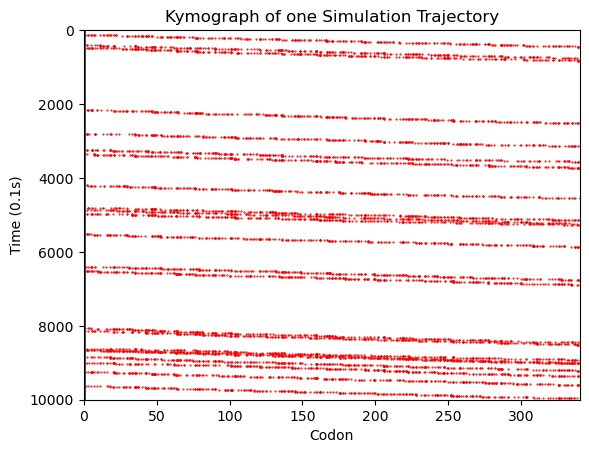

In [107]:
fig,ax = plt.subplots(1,1)
c = ax.plot(soln.ribosome_array[0][:,:,6] ,'r.',markersize=1)
newx = [x.get_xdata() for x in c]
newy =  [x.get_ydata() for x in c]
[c[x].set_xdata(newy[x]) for x in range(len(c))]
[c[x].set_ydata(newx[x]) for x in range(len(c))]
ax.set_title('Kymograph of one Simulation Trajectory')
ax.set_xlabel('Codon')
ax.set_ylabel('Time (0.1s)')
ax.set_xlim([0,max(newy[0])])
ax.set_ylim([0,max(newx[0])])
ax.invert_yaxis()

In [135]:
#currently you can pass a CDS directly, or a list of stepping rates to the model solver, this is ambigious and needs to change!!
# Manually induce a pause!

stepping_rate_list = largest_CDS.kelong
stepping_rate_list[100] = .1
t = np.linspace(0,1000,10001)

k_initiation = .03
k_termination = 10
soln = rsnp.solver.solve_ssa(stepping_rate_list, t, probe_list = [[1,5,10]], ki = k_initiation, kt=k_termination)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

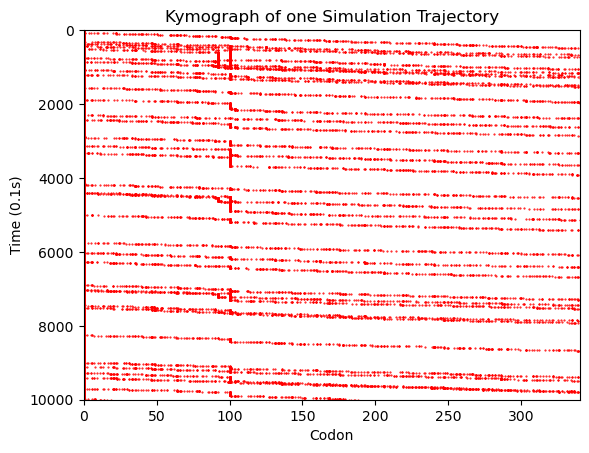

In [115]:
fig,ax = plt.subplots(1,1)
c = ax.plot(soln.ribosome_array[0][:,:,6] ,'r.',markersize=1)
newx = [x.get_xdata() for x in c]
newy =  [x.get_ydata() for x in c]
[c[x].set_xdata(newy[x]) for x in range(len(c))]
[c[x].set_ydata(newx[x]) for x in range(len(c))]
ax.set_title('Kymograph of one Simulation Trajectory')
ax.set_xlabel('Codon')
ax.set_ylabel('Time (0.1s)')
ax.set_xlim([0,max(newy[0])])
ax.set_ylim([0,max(newx[0])])
ax.invert_yaxis()

In [125]:
soln.intensity_arr.sum() #hang on theres no intensity? Yes because we didn't tag it with any fluorescent epitopes!

0

In [117]:
rsnp.cdict.tag_dict # Here are some of our tagging options

{'T_SunTag': 'EELLSKNYHLENEVARLKK',
 'T_Flag': 'DYKDDDDK',
 'T_Hemagglutinin': 'YPYDVPDYA',
 'T_Myc': 'EQKLISEEDL',
 'T_Strep': 'WSHPQFEK',
 'T_Hist': 'HHHHHH',
 'T_V5': 'GKPIPNPLLGLDST',
 'T_TC': 'CCPGCC'}

In [45]:
rsnp.cdict.tag_full['T_Flag'] #lets add a full 10x tflag

'ATGGACTACAAGGACGACGACGACAAAGGTGACTACAAAGATGATGACGATAAAGGCGACTATAAGGACGATGACGACAAGGGCGGAAACTCACTGATCAAGGAAAACATGCGGATGAAGGTGGTGATGGAGGGCTCCGTGAATGGTCACCAGTTCAAGTGCACCGGAGAGGGAGAGGGAAACCCGTACATGGGAACTCAGACCATGCGCATTAAGGTCATCGAAGGAGGTCCGCTGCCGTTCGCTTTCGATATCCTGGCCACTTCGTTCGGAGGAGGGTCGCGCACGTTCATCAAGTACCCGAAGGGAATCCCGGACTTCTTTAAGCAGTCATTCCCGGAAGGATTCACTTGGGAACGGGTGACCCGGTATGAAGATGGAGGTGTGGTGACTGTCATGCAAGATACTTCGCTGGAGGATGGGTGCCTCGTGTACCACGTCCAAGTCCGCGGAGTGAATTTCCCGTCCAACGGACCAGTGATGCAGAAAAAGACGAAGGGTTGGGAACCTAATACTGAAATGATGTACCCCGCAGACGGAGGGCTGAGGGGCTACACCCACATGGCGCTGAAGGTCGACGGAGGAGATTACAAGGATGACGACGATAAGCAACAAGATTACAAAGACGATGATGACAAGGGCCAGCAGGGCGACTACAAGGACGACGACGACAAGCAGCAGGACTACAAAGATGACGATGATAAAGGAGGAGGACATCTGTCCTGTTCGTTCGTGACCACCTACAGATCAAAGAAAACCGTGGGAAACATCAAGATGCCGGGCATTCATGCCGTCGACCACCGCCTGGAGCGGCTCGAAGAATCAGACAATGAGATGTTCGTCGTGCAAAGAGAACATGCCGTGGCCAAGTTCGCGGGACTGGGAGGCGGTGGAGGCGATTACAAAGACGATGATGACAAGGGTGACTATAAAGACGACGATGACAAAGGGGATTACAAGGATGATGATGATAAGGGAGGCGGTGGATCAGGTGGAGGA

In [122]:
rsnp.seqmanip.nt2aa(rsnp.cdict.tag_full['T_Flag'])

'MDYKDDDDKGDYKDDDDKGDYKDDDDKGGNSLIKENMRMKVVMEGSVNGHQFKCTGEGEGNPYMGTQTMRIKVIEGGPLPFAFDILATSFGGGSRTFIKYPKGIPDFFKQSFPEGFTWERVTRYEDGGVVTVMQDTSLEDGCLVYHVQVRGVNFPSNGPVMQKKTKGWEPNTEMMYPADGGLRGYTHMALKVDGGDYKDDDDKQQDYKDDDDKGQQGDYKDDDDKQQDYKDDDDKGGGHLSCSFVTTYRSKKTVGNIKMPGIHAVDHRLERLEESDNEMFVVQREHAVAKFAGLGGGGGDYKDDDDKGDYKDDDDKGDYKDDDDKGGGGSGGGGSLQ'

In [136]:
newseq = rsnp.cdict.tag_full['T_Flag'] + largest_CDS.nt_seq
tagged_CDS = rsnp.seqmanip.seq_to_CDS_obj(newseq)['0'][0] 
tagged_CDS.generate_3frame_tags()

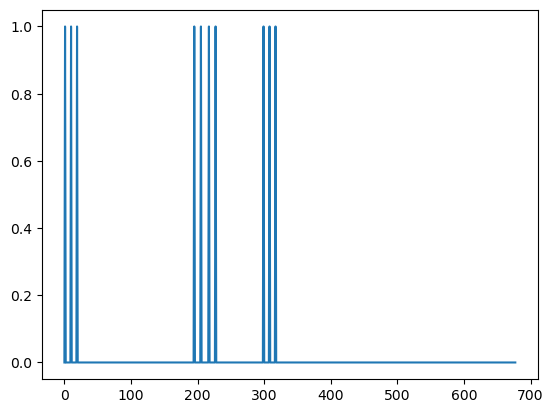

In [144]:
plt.plot(tagged_CDS.probe_mat[0,:])

In [140]:
t = np.linspace(0,1000,10001)
soln = rsnp.solver.solve_ssa(tagged_CDS, t)

In [141]:
soln.intensity_arr.sum() #now we should have intensity

160268

Text(0, 0.5, 'Intensity (# probes)')

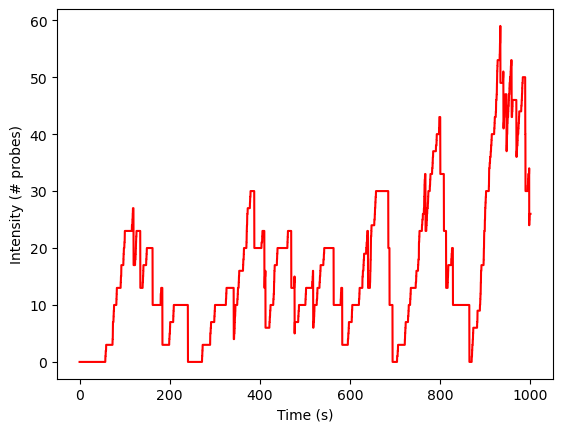

In [142]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')

In [146]:
# Creating an mRNA model 

# takes a CDS object and a name
mRNA_length = len(tagged_CDS.kelong) 
model = rsnp.tasep_model(tagged_CDS, 'test') # model object

In [147]:
model.__dict__

{'name': 'test',
 '_length': 678,
 'particle_size': 9,
 'footprint': 9,
 '_max_particles': 80,
 '_state_mat': array(0),
 '_probe_mat': array([[0., 1., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]]),
 '_n_colors': 1,
 '_resource_mat': array(0),
 '_propensities': [],
 '_parameters': [],
 '_prop_ids': [],
 '_constant_rxn_bool': [],
 '_constant_reactions': [],
 '_ribosome_reactions': [],
 '_n_rxns': 0,
 '_n_pars': 0,
 '_n_kelong': 1,
 '_n_frames': 1,
 '_n_states': 0,
 '_n_resources': 0,
 '_rxn_mat': array([], shape=(0, 8), dtype=float64),
 '_TranslationModel__rxn_size': 8,
 '_TranslationModel__default_colors': ['#07BEB8',
  '#8F3985',
  '#5EDA6A',
  '#FA5E5E'],
 '_state_names': [],
 '_resource_names': [],
 '_rib_arr0': array([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0

In [51]:
## overwite the default kelongation matrix 
kelong_mat = np.zeros([3, mRNA_length+1])
kelong_mat[0, :-1] = rsnp.propf.get_k(tagged_CDS.nt_seq, .033, 10, 10)[1:-1]
kelong_mat[1, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[1:-2], .1, 10, 10)[1:-1]
kelong_mat[2, :-2] = rsnp.propf.get_k(tagged_CDS.nt_seq[2:-1], .1, 10, 10)[1:-1]
kelong_mat[0, -2] = 0

model._kelong_mat = kelong_mat #override the current kelongation mat

footprint = 9
last_codon = len(tagged_CDS.kelong)-1 
parameters = [0.03, 0.01, 10, .4, 0]


# k is the parameters, t = timepoint, p = ribosome_array/array, occupation array, lattice array, probe matrix, state matrix
# r = resources, nr = number of ribosomes
# Check the docstring!

# Lattice based reactions, happen at specific locations, in this case the initiation and termination site
init = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[0:0+footprint]))*k[0]
model.add_lattice_reaction(init, parameters, rxn_name = 'initiation', frame=0, loc=0, dexist=1,)

# Alternative start site
init_100 = lambda k,t,p,ke,o,l,pr,s,r,nr: (1-np.any(l[100:100+footprint]))*k[1]
model.add_lattice_reaction(init_100, parameters, rxn_name = 'initiation', frame=0, loc=100, dexist=1,)

leave = lambda k,t,p,ke,o,l,pr,s,r,nr: l[last_codon]*k[2] #(lattice location last_codon = 1) * parameter
model.add_lattice_reaction(leave, parameters, rxn_name='termination', exclusion=0, frame=0, loc=last_codon, dexist=-1,)

# ribosome based reactions
#default stepping
                                                # agent frame, agent location
elong_step = lambda k,t,p,ke,o,l,pr,s,r,nr: [ (ke[p[i,2], p[i,3]])*(1 - sum(l[p[i,3]+1:p[i,3]+footprint])) for i in range(nr)]
model.add_ribosome_reaction(elong_step, parameters, rxn_name='elongation', exclusion=1, dloc=1) 


# finally specify which reactions are ribosome specific, this should be automated in the future
model._ribosome_reactions = [3,]
model._constant_reactions = [0,1,2]
model._lattice_arr0 = np.zeros([model._length+1], dtype=int)


In [149]:
model.add_ribosome_reaction?

Signature:
model.add_ribosome_reaction(
    propensity,
    parameters,
    rxn_name='',
    exclusion=0,
    dexist=0,
    dframe=0,
    dloc=0,
    dprobes=[],
    dprobe_inds=[],
    dstates=[],
    dstate_inds=[],
    dresources=[],
    dresource_inds=[],
)
Docstring: <no docstring>
File:      c:\users\wsraymon\github\rsnapsim\rsnapsim\translationmodel.py
Type:      method

In [150]:
model.add_lattice_reaction?

Signature:
model.add_lattice_reaction(
    propensity,
    parameters,
    rxn_name='',
    frame=0,
    loc=0,
    exclusion=0,
    dexist=0,
    dframe=0,
    dloc=0,
    dprobes=[],
    dprobe_inds=[],
    dstates=[],
    dstate_inds=[],
    dresources=[],
    dresource_inds=[],
)
Docstring: <no docstring>
File:      c:\users\wsraymon\github\rsnapsim\rsnapsim\translationmodel.py
Type:      method

In [52]:
soln = rsnp.solver.solve_ssa(model, t)

Text(0, 0.5, 'Intensity (# probes)')

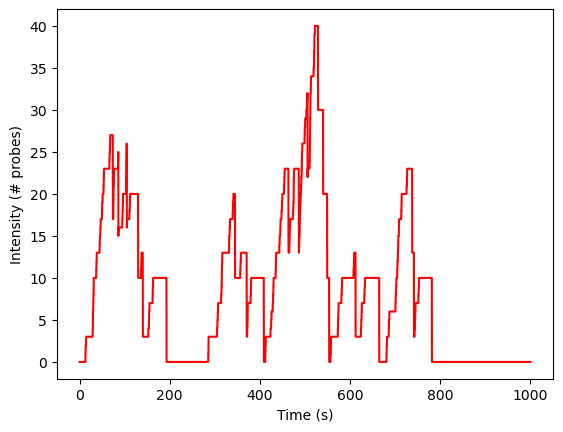

In [55]:
plt.plot(soln.t, soln.intensity_arr[0],'r')
plt.xlabel('Time (s)')
plt.ylabel('Intensity (# probes)')